# Figures Section 3
Here, the figures corresponding to the section on cell line single cell data in the final report will be generated

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and Files ###
root = '../../'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = f'{root}Generated Data/Final Report/Section 3/'
metadata_dir = f"{data_dir}/cell_line_mapping.csv"
higashi_embed = f'{root}Data/ramani_higashi/output/embed/exp_zinb3_0_origin.npy'

In [3]:
### Imports ###
import sys
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_ot_optim, subset_clr_data, generate_clustermap, generate_umap, long_transform, generate_marginal_plot, hic_ot_bulk_threshold_sequential, generate_violin_plot, ot_mass_threshold
from time import perf_counter
from umap import UMAP
from itertools import combinations

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
### Importing Data ###
clrs = import_cool_dir(data_dir)
metadata_df = pd.read_csv(metadata_dir)
metadata_df

,cell_name,cell_line
0,cell0_HeLa_,HeLa
1,cell1_HAP1_,HAP1
2,cell2_HeLa_,HeLa
3,cell3_HeLa_,HeLa
4,cell4_HeLa_,HeLa
...,...,...
615,cell615_K562_,K562
616,cell616_K562_,K562
617,cell617_GM12878_,GM12878
618,cell618_K562_,K562


## Panel A
Higashi embeddings of the ramani dataset.

### Loading Data

In [8]:
cell_embeddings = np.load(higashi_embed)

### UMAP

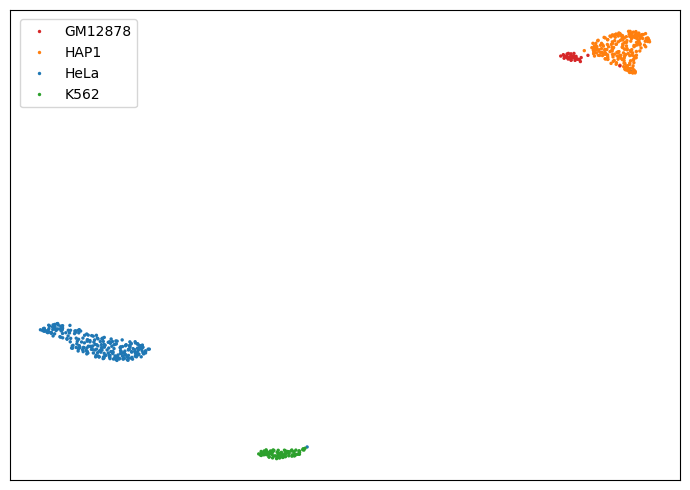

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=metadata_df["cell_line"], ax=ax, s=6, linewidth=0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(0.015, 0.98), loc=2, borderaxespad=0., ncol=1)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

## Panel B
Clustermap of UOT data

TODO:
- Replace with larger subset

### Generating Data

In [32]:
### Setting Parameters ###
res_s3b = 4
thres_s3b = 0
reg_m_s3b = 0.1
count_s3b = 30

    # Subset
unbalanced_subset = subset_clr_data(
    data_dir,
    metadata_df,
    count_s3b,
    type_col="cell_line",
    iqr_rule=1.5
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [33]:
local_save_dir = f'{save_dir}Main Figure/Panel B/'

    # OT
unbalanced_results = hic_ot_optim(
    unbalanced_subset,
    "chr1",
    "threshold",
    "max",
    thres=thres_s3b,
    thres_type="percentile",
    unbalanced=reg_m_s3b,
    rebin_factor = res_s3b
)

    # Saving
unbalanced_results.to_csv(f'{local_save_dir}subset_ot_seed=42_count={count_s3b}_res={res_s3b}mb_thres={thres_s3b}_reg_m={reg_m_s3b}.csv')

100%|██████████| 7140/7140 [12:29<00:00,  9.52it/s]


In [35]:
### Loading and long transform ###
unbalanced_results = pd.read_csv(f'{local_save_dir}subset_ot_seed=42_count={count_s3b}_res={res_s3b}mb_thres={thres_s3b}_reg_m={reg_m_s3b}.csv', index_col=0)
unbalanced_results_long = long_transform(unbalanced_results, metadata_df, type_col="cell_line")

### Clustermap

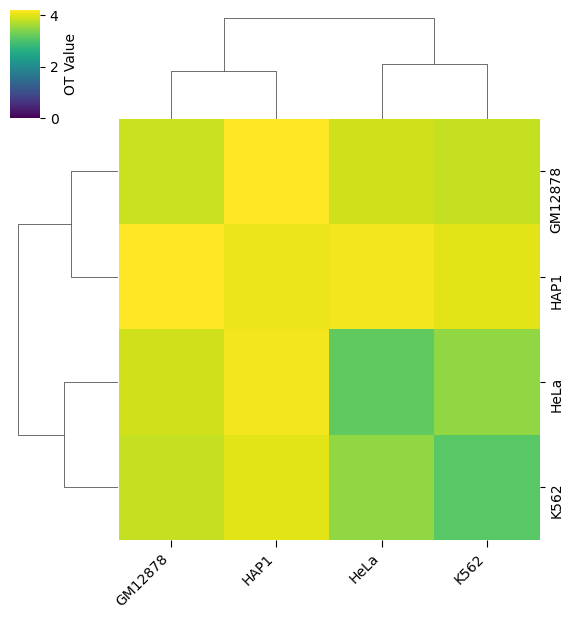

In [36]:
generate_clustermap(
    unbalanced_results_long,
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(6,6)
)

## Panel C
Marginal plot of UOT to show lack of mass bias as the issue

TODO:
- Replace with larger subset

In [40]:
### Generating Mass DF ###
mass_df = ot_mass_threshold(
    unbalanced_subset,
    "chr1",
    thres_s3b
)

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


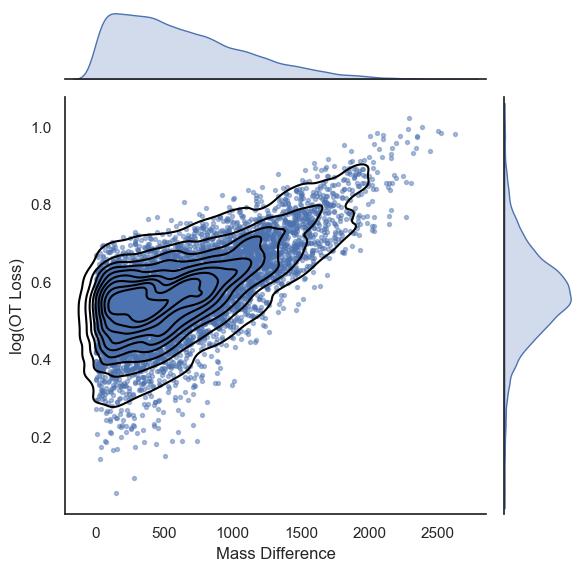

In [42]:
### Marginal Plot
generate_marginal_plot(unbalanced_results_long, mass_df, cell_name_col="cell_name")

## Panel D
UMAP of UOT data

TODO:
- Replace with larger subset

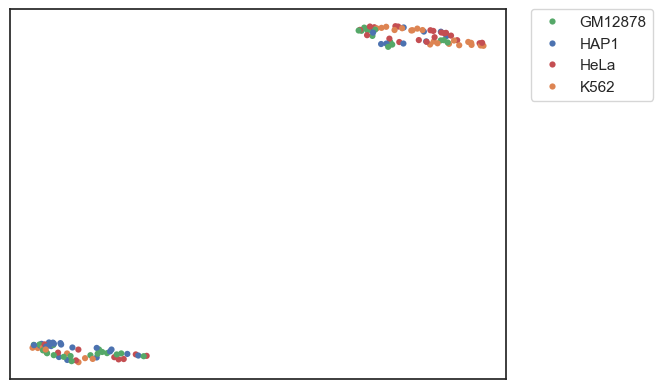

In [48]:
embed = generate_umap(
    unbalanced_results,
    metadata_df,
    type_col="cell_line"
)

## Supplementary Figure 1
UOT on different thresholds and resolutions

### Helper Functions

In [10]:
### Helper function for importing data ###
def import_data_sup1(dir: str) -> dict[str, pd.DataFrame]:
    '''
        Imports unbalanced OT data for section 3, supplementary
        figure 1 as a dictionary with resolution and threshold as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as
            "[res] Mb, τ=[thres]".
    '''
    # Setting patterns
    pattern = os.path.join(dir, "unbalanced_LINES_SF1_res=*_thres=*_reg_m=0.1_count=3.csv")
    regex = r"unbalanced_LINES_SF1_res=(?P<res>.+?)_thres=(?P<thres>.+?)_reg_m=0\.1_count=3\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            res = match.group("res")
            thres  = match.group("thres")
            key = f"{res} Mb, τ={thres}%"
            data_dict[key] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

In [13]:
### Helper function for correspondences ###
def correspondence_matrix(results: dict[str, pd.DataFrame]) -> pd.DataFrame:
    '''
        Takes OT results in a dict given with resolution
        and threshold as keys and returns a dataframe
        giving linear correspondence between all methods.

        Parameters
        ----------
        results : dict[str, pd.DataFrame]
            Results imported as a dict by import_data_sup1.
            
        Returns
        -------
        cor_mat : pd.DataFrame
            Symmetric dataframe giving Pearson r2 between upper
            triangles
    '''
    keys = list(results.keys())
    n    = len(keys)

    # Extract upper triangles
    triags = {}
    for key, df in results.items():
        matrix = df.values
        idx = np.triu_indices(matrix.shape[0], k=1)  # k=1 excludes the diagonal
        triags[key] = matrix[idx].astype(float)
    
    # Correspondence matrix
    cor_mat = pd.DataFrame(np.ones((n, n)), index=keys, columns=keys)

    for key_a, key_b in combinations(keys, 2):
        vec_a = triags[key_a]
        vec_b = triags[key_b]

        r = np.corrcoef(vec_a, vec_b)[0, 1]
        r_squared = r ** 2

        cor_mat.loc[key_a, key_b] = r_squared
        cor_mat.loc[key_b, key_a] = r_squared 
    
    return cor_mat

### Generating Data

In [7]:
### Setting parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 3/Supplementary Figure 1/"
binning_factors = [8, 4, 2, 1]
thresholds = [95, 90, 75, 50, 0]
subset_sf1 = subset_clr_data(
    data_dir,
    metadata_df,
    3,
    type_col="cell_line"
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [6]:
### Unbalanced ###
time_path = f"{local_save_dir}section3_sf1_ot_unbalanced_times.csv"

for factor in binning_factors:
    for thres in thresholds:
        print(f"OT FOR RES={factor}, THRES={thres}")
        if not os.path.exists(f"{local_save_dir}unbalanced_LINES_SF1_res={factor}_thres={thres}_reg_m=0.1_count=3.csv"):
            time = perf_counter()

            # OT
            results = hic_ot_bulk_threshold_sequential(
                subset_sf1, 
                "chr1",
                norm="max",
                thres=thres,
                thres_type="percentile",
                unbalanced=0.1,
                rebin_factor=factor)

            # Updating time file
            time = perf_counter() - time

                # Cast to strings to ensure proper indexing
            res_str = str(factor)
            thres_str = str(thres)

                # Make or import csv
            if os.path.exists(time_path):
                df_calc = pd.read_csv(time_path, index_col=0)
                df_calc.index = df_calc.index.astype(str)
            else:
                df_calc = pd.DataFrame()

                # Insert value in row
            df_calc.at[thres_str, res_str] = time

                # Save to CSV
            df_calc.to_csv(time_path)
            
            results.to_csv(f"{local_save_dir}unbalanced_LINES_SF1_res={factor}_thres={thres}_reg_m=0.1_count=3.csv")

OT FOR RES=8, THRES=0
OT FOR RES=4, THRES=0
OT FOR RES=2, THRES=0
OT FOR RES=1, THRES=0


  0%|          | 0/66 [00:00<?, ?it/s]

: 

### Panel A
Times

(-4.75, 100.0)

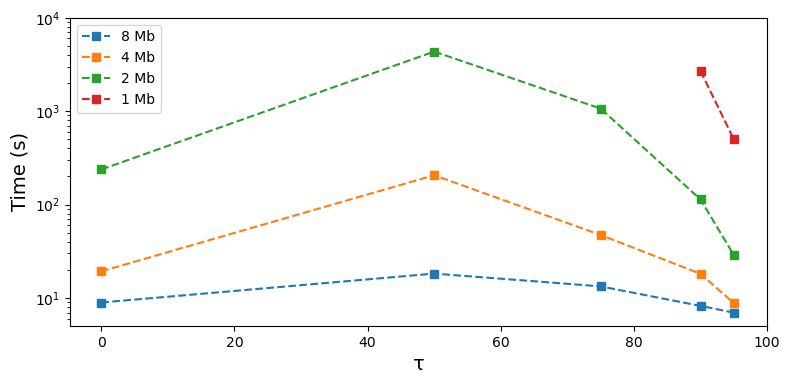

In [8]:
# Importing time
time_path_unbalanced = f"{local_save_dir}section3_sf1_ot_unbalanced_times.csv"
times_s3unbalanced = pd.read_csv(time_path_unbalanced, index_col=0).sort_index(ascending=True)
res_list = ["8", "4", "2", "1"]
labels = [
    "8 Mb",
    "4 Mb",
    "2 Mb",
    "1 Mb"
]

# Initialize Figure
fig, ax = plt.subplots(1, 1, figsize=(9, 4))

# Figure Balanced
for res in res_list:
    ax.plot(times_s3unbalanced[res].index, times_s3unbalanced[res], linestyle='--', marker='s')
ax.set_yscale('log')
ax.legend(labels=labels)
ax.set_xlabel("τ", size=14)
ax.set_ylabel("Time (s)", size=14)
ax.set_ylim(top=1e4)
ax.set_xlim(right=100)

### Panel B
Clustermap

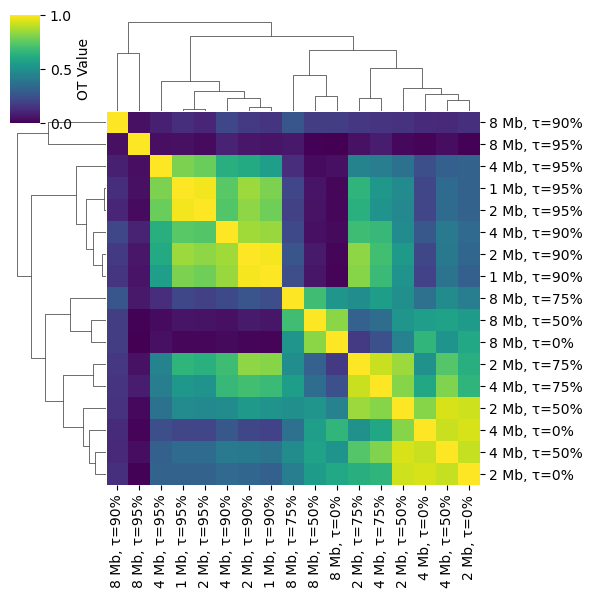

In [13]:
# Unbalanced
results_unbalanced = import_data_sup1(local_save_dir)
cor_mat_balanced = correspondence_matrix(results_unbalanced)
g = sns.clustermap(
    cor_mat_balanced,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(6,6)
)

plt.show()

## Supplementary Figure 2
Testing different reg_m values

### Helper Functions

In [19]:
### Helper function for importing data ###
def import_data_sup2(dir: str) -> dict[str, pd.DataFrame]:
    '''
        Imports unbalanced OT data for section 3, supplementary
        figure 2 as a dictionary with resolution and threshold as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as
            "[res] Mb, τ=[thres]".
    '''
    # Setting patterns
    pattern = os.path.join(dir, "unbalanced_LINES_SF2_res=4_thres=0_reg_m=*_count=3.csv")
    regex = r"unbalanced_LINES_SF2_res=4_thres=0_reg_m=(?P<reg_m>\d*\.?\d+)_count=3\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            reg_m = match.group("reg_m")
            key = f"reg_m={reg_m}"
            data_dict[key] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

### Generating Data

In [5]:
### Setting parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 3/Supplementary Figure 2/"
reg_m_list = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]
subset_sf2 = subset_clr_data(
    data_dir,
    metadata_df,
    3,
    type_col="cell_line"
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [6]:
time_path = f"{local_save_dir}section3_sf2_ot_reg_m_times.csv"
for reg_m in reg_m_list:
    print(f"OT FOR REG_M={reg_m}")
    if not os.path.exists(f"{local_save_dir}unbalanced_LINES_SF2_res=4_thres=0_reg_m={reg_m}_count=3.csv"):
        time = perf_counter()

        # OT
        results = hic_ot_bulk_threshold_sequential(
            subset_sf2, 
            "chr1",
            norm="max",
            thres=0,
            thres_type="percentile",
            unbalanced=reg_m,
            rebin_factor=4)

        # Updating time file
        time = perf_counter() - time

            # Cast to strings to ensure proper indexing
        res_str = "4 Mb, 0%"
        reg_m_str = str(reg_m)

            # Make or import csv
        if os.path.exists(time_path):
            df_calc = pd.read_csv(time_path, index_col=0)
            df_calc.index = df_calc.index.astype(str)
        else:
            df_calc = pd.DataFrame()

            # Insert value in row
        df_calc.at[reg_m_str, res_str] = time

            # Save to CSV
        df_calc.to_csv(time_path)
        
        results.to_csv(f"{local_save_dir}unbalanced_LINES_SF2_res=4_thres=0_reg_m={reg_m}_count=3.csv")

OT FOR REG_M=0.001


100%|██████████| 66/66 [00:10<00:00,  6.48it/s]


OT FOR REG_M=0.01


100%|██████████| 66/66 [00:10<00:00,  6.16it/s]


OT FOR REG_M=0.1


...

100%|██████████| 66/66 [18:21<00:00, 16.68s/it]


OT FOR REG_M=100.0


100%|██████████| 66/66 [19:11<00:00, 17.45s/it]


OT FOR REG_M=1000.0


100%|██████████| 66/66 [23:06<00:00, 21.01s/it]


### Panel A
Times

Text(0, 0.5, 'Time (s)')

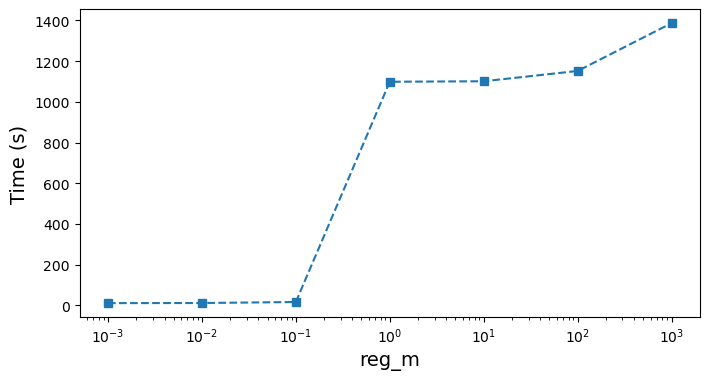

In [9]:
# Importing times
time_path = f"{local_save_dir}section3_sf2_ot_reg_m_times.csv"
times_sf2 = pd.read_csv(time_path, index_col=0).sort_index(ascending=True)
reg_m_list = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]

# Initialize Figure
fig, ax = plt.subplots(figsize=(8, 4))

# Figure Balanced
ax.plot(times_sf2["4 Mb, 0%"].index, times_sf2["4 Mb, 0%"], linestyle='--', marker='s')
ax.set_xscale('log')
ax.set_xlabel("reg_m", size=14)
ax.set_ylabel("Time (s)", size=14)

### Panel B
Clustermap

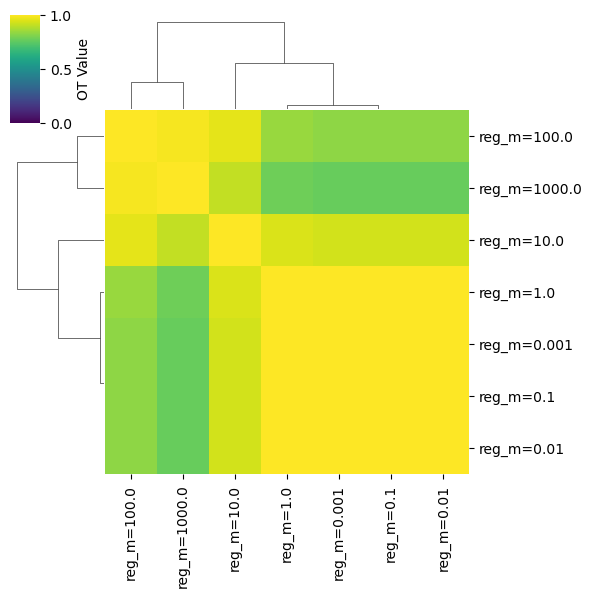

In [20]:
results = import_data_sup2(local_save_dir)
cor_mat = correspondence_matrix(results)
g = sns.clustermap(
    cor_mat,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(6,6)
)

plt.show()

## Supplementary Figure 3
Histograms of OT cost with subsets

### Helper Functions

In [21]:
### Helper function for importing data ###
def import_data_sup3(dir: str) -> dict[str, pd.DataFrame]:
    '''
        Imports OT data for section 3, supplementary
        figure 3 as a dictionary with the seed as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as
            "seed={seed}".
    '''
    # Setting patterns
    pattern = os.path.join(dir, "unbalanced_LINES_SF3_res=4_thres=0_reg_m=0.1_count=10_seed=*.csv")
    regex = r"unbalanced_LINES_SF3_res=4_thres=0_reg_m=0\.1_count=10_seed=(?P<seed>.+?)\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            seed = match.group("seed")
            data_dict[int(seed)] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

### Generating Data

In [22]:
### Setting parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 3/Supplementary Figure 3/"
seeds = [1, 2, 3, 4, 5]

In [ ]:
### Data per seed ###
for seed in seeds:
    # Subsetting
    subset = subset_clr_data(
        data_dir,
        metadata_df,
        10,
        seed,
        type_col="cell_line"
    )

    # OT and saving
    print(f"OT FOR seed={seed}")
    if not os.path.exists(f"{local_save_dir}unbalanced_LINES_SF3_res=4_thres=0_reg_m=0.1_count=10_seed={seed}.csv"):
        # OT
        results = hic_ot_optim(
            subset, 
            "chr1",
            selection="threshold",
            norm="max",
            unbalanced=0.1,
            thres=0,
            thres_type="percentile",
            rebin_factor=4)
        
        results.to_csv(f"{local_save_dir}unbalanced_LINES_SF3_res=4_thres=0_reg_m=0.1_count=10_seed={seed}.csv")

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


OT FOR seed=1


100%|██████████| 780/780 [00:58<00:00, 13.32it/s]
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


OT FOR seed=2


100%|██████████| 780/780 [01:28<00:00,  8.79it/s]
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


...

100%|██████████| 780/780 [02:20<00:00,  5.56it/s]
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


OT FOR seed=4


100%|██████████| 780/780 [02:01<00:00,  6.44it/s]
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


OT FOR seed=5


100%|██████████| 780/780 [01:56<00:00,  6.70it/s]


### Figure
Density plot

In [26]:
### Loading Data ###
results_subsets_unbalanced = import_data_sup3(local_save_dir)

Text(0.5, 0, 'OT Value')

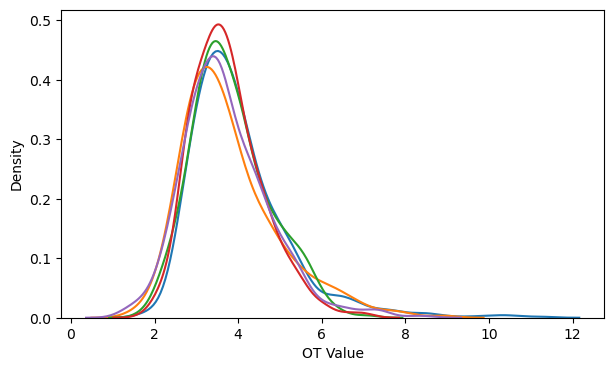

In [28]:
### Figure ###
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

# Panels
for seed in seeds:
    # Extract upper triangle
    matrix = results_subsets_unbalanced[seed].values
    
    idx = np.triu_indices(matrix.shape[0], k=1)
    upper = matrix[idx]

    # Balanced
    sns.kdeplot(
        upper,
        ax=ax
    )
ax.set_xlabel("OT Value")

## Supplementary Figure 4
Violin plots before and after trimming data.

### Panel A
Before trimming

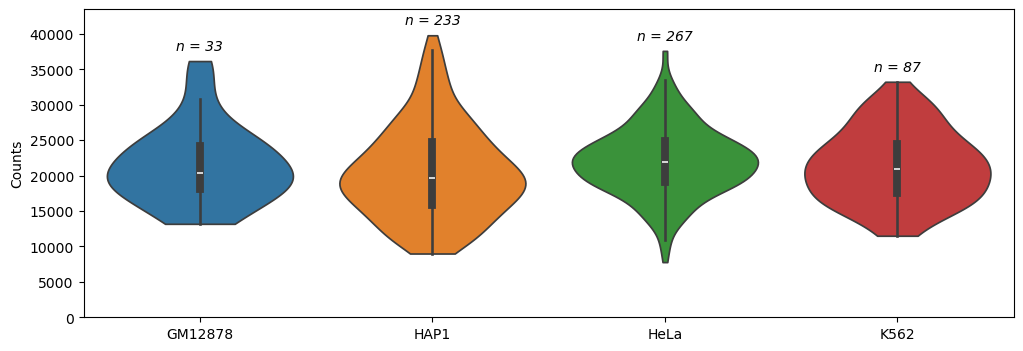

In [29]:
generate_violin_plot(
    clrs,
    metadata_df,
    fig_size=(12, 4),
    cell_type_col="cell_line"
)

### Panel B
After trimming

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


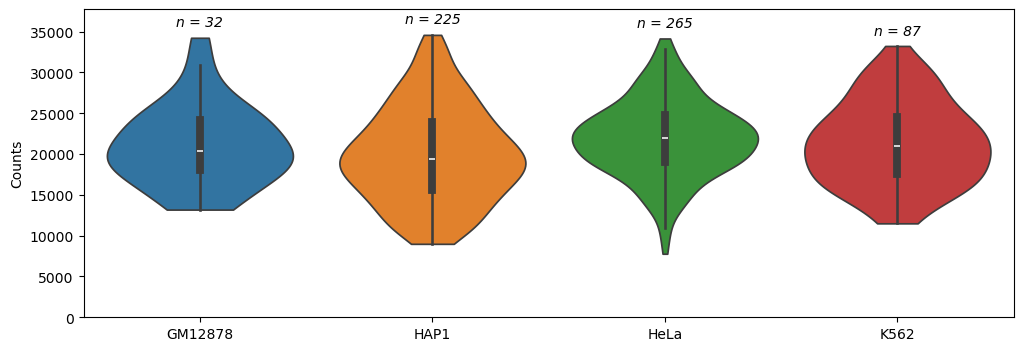

In [30]:
trimmed = subset_clr_data(
    data_dir,
    metadata_df,
    iqr_rule = 1.5,
    type_col="cell_line"
)
generate_violin_plot(
    trimmed,
    metadata_df,
    fig_size=(12, 4),
    cell_type_col="cell_line"
)